# 1. Project Overview

## 1.1 Introduction

Credit worthiness assessment is an important data-driven process used to evaluate the likelihood that an applicant will meet their financial obligations. This project analyses the CreditWorthiness dataset and uses the accompanying Python notebook to explore applicant characteristics and develop a machine-learning approach for supporting credit worthiness assessment.

The dataset contains **1,000 records** and **21 variables**. The project performs data preparation, exploratory analysis, and predictive modelling to identify patterns in the available credit information. The notebook applies a machine-learning workflow to assess and predict credit worthiness from the available applicant information.

## 1.2 Problem Statement

Credit decisions often involve large volumes of applicant information with different numerical and categorical characteristics. The challenge addressed in this project is to transform the available credit data into meaningful insights and to develop a predictive approach that can support the assessment of credit worthiness.

The project therefore focuses on understanding the dataset, preparing the data for analysis, identifying relevant patterns, and evaluating whether machine-learning models can provide useful predictions from the available information.

The primary problem addressed by the data is the quantification of financial risk during the loan approval process. Specifically, the institution needs to determine whether a potential borrower is "creditworthy" (Good) or "risky" (Bad) based on a variety of personal and financial attributes.The manual assessment of these risks is often inconsistent or slow. Therefore, the challenge is to use historical data—including factors like checking account balances, loan duration, credit history, purpose of the loan, and demographic info (age, job type)—to build a model that can accurately predict the creditScore of new applicants.

## 1.3 Purpose of the Project

The purpose of this project is to:

- Analyse and understand the structure and characteristics of the credit worthiness dataset.
- Identify data quality issues and prepare the data for analysis and modelling.
- Explore relationships and patterns among variables that may be associated with credit worthiness.
- Apply the preprocessing and feature preparation steps implemented in the notebook.
- Develop and evaluate machine-learning model(s) for predicting or assessing credit worthiness.
- Use the findings to provide practical insights and recommendations for improving data-driven credit assessment.


In [15]:
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [16]:
df = pd.read_excel(r"C:\Users\user\Downloads\Credit_worthy\CreditWorthiness.xlsx")

In [17]:
df.head()

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,Prop,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore
0,0 <= Rs. < 2000,9,all settled till now,Business,13790,Rs. < 1000,1 to 4 years,2,married or widowed male,no one,...,real estate,27,bank,own,1,employee with official position,1,yes,no,good
1,0 <= Rs. < 2000,15,dues not paid earlier,electronics,15250,no savings account,more than 7 years,4,single male,"yes, guarantor",...,real estate,50,none,own,2,employee with official position,1,yes,no,good
2,0 <= Rs. < 2000,36,none taken/all settled,Business,19410,Rs. < 1000,more than 7 years,4,single male,no one,...,Unknown,61,none,free,1,"employed either in management, self or in high...",1,yes,no,bad
3,0 <= Rs. < 2000,48,none taken/all settled,Business,144090,Rs. < 1000,1 to 4 years,2,single male,no one,...,Other cars etc.,25,none,own,1,employee with official position,1,yes,no,bad
4,no checking account,24,all settled till now,electronics,31690,Rs. < 1000,less than 1 year,4,divorced or separated or married female,no one,...,life insurance/building society,26,none,own,1,employee with official position,1,yes,no,good


In [18]:
df.columns = df.columns.str.capitalize()

In [19]:
df.head()

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,Inrate,Msg,Oparties,...,Prop,Age,Inplans,Htype,Numcred,Jobtype,Ndepend,Telephone,Foreign,Creditscore
0,0 <= Rs. < 2000,9,all settled till now,Business,13790,Rs. < 1000,1 to 4 years,2,married or widowed male,no one,...,real estate,27,bank,own,1,employee with official position,1,yes,no,good
1,0 <= Rs. < 2000,15,dues not paid earlier,electronics,15250,no savings account,more than 7 years,4,single male,"yes, guarantor",...,real estate,50,none,own,2,employee with official position,1,yes,no,good
2,0 <= Rs. < 2000,36,none taken/all settled,Business,19410,Rs. < 1000,more than 7 years,4,single male,no one,...,Unknown,61,none,free,1,"employed either in management, self or in high...",1,yes,no,bad
3,0 <= Rs. < 2000,48,none taken/all settled,Business,144090,Rs. < 1000,1 to 4 years,2,single male,no one,...,Other cars etc.,25,none,own,1,employee with official position,1,yes,no,bad
4,no checking account,24,all settled till now,electronics,31690,Rs. < 1000,less than 1 year,4,divorced or separated or married female,no one,...,life insurance/building society,26,none,own,1,employee with official position,1,yes,no,good


In [20]:
df.duplicated().sum()

0

In [21]:
df.isnull().sum()

Cbal           0
Cdur           0
Chist          0
Cpur           0
Camt           0
Sbal           0
Edur           0
Inrate         0
Msg            0
Oparties       0
Rdur           0
Prop           0
Age            0
Inplans        0
Htype          0
Numcred        0
Jobtype        0
Ndepend        0
Telephone      0
Foreign        0
Creditscore    0
dtype: int64

In [30]:
df.describe()

,Cdur,Camt,Inrate,Age,Numcred,Ndepend
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,32592.58000,2.973000,35.546000,1.407000,1.155000
std,12.058814,28227.36876,1.118715,11.375469,0.577654,0.362086
min,4.000000,2380.00000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,13535.00000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,23075.00000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,39602.50000,4.000000,42.000000,2.000000,1.000000
max,72.000000,184120.00000,4.000000,75.000000,4.000000,2.000000


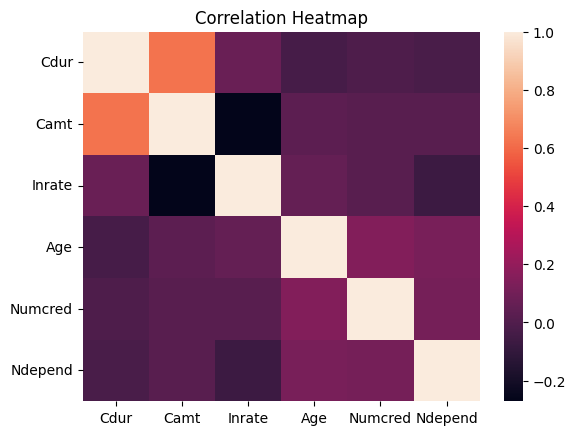

In [29]:
 4. #EXPLORATORY DATA ANALYSIS (EDA)
# =========================================


# Target distribution (Assume target column = 'Creditworthy')
if 'Creditworthy' in df.columns:
    df['Creditworthy'].value_counts().plot(kind='bar')
    plt.title("Target Variable Distribution")
    plt.show()

# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
# 5. FEATURE ENGINEERING
# =========================================

# Convert categorical → numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Assume last column is target if unknown
target_col = df_encoded.columns[-1]

X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print("\nTarget Column:", target_col)



Target Column: Creditscore_good


In [24]:
X.shape, y.shape

((1000, 49), (1000,))

In [25]:
# 6. TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# 7. FEATURE SCALING
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# 8. MACHINE LEARNING MODELS
# =========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier()
}


In [28]:
# 9. TRAINING & EVALUATION
# =========================================

for name, model in models.items():
    print(f"\n{name}")
    print("-" * 30)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression
------------------------------
Accuracy: 0.785

Confusion Matrix:
 [[ 30  26]
 [ 17 127]]

Classification Report:
               precision    recall  f1-score   support

       False       0.64      0.54      0.58        56
        True       0.83      0.88      0.86       144

    accuracy                           0.79       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.78      0.79      0.78       200


Random Forest
------------------------------
Accuracy: 0.79

Confusion Matrix:
 [[ 27  29]
 [ 13 131]]

Classification Report:
               precision    recall  f1-score   support

       False       0.68      0.48      0.56        56
        True       0.82      0.91      0.86       144

    accuracy                           0.79       200
   macro avg       0.75      0.70      0.71       200
weighted avg       0.78      0.79      0.78       200



# 2. Conclusion and Key Insights

The Credit Worthiness project demonstrates how data analysis and machine learning can support credit-related decision-making. The dataset contains **1,000 observations** and **21 variables**, providing a structured basis for exploring applicant characteristics and building predictive models. Direct inspection of the uploaded dataset identified **0 missing values** across all cells.

The notebook follows a data science workflow that moves from data preparation and exploration to predictive modelling and evaluation. The notebook includes the following model(s): LogisticRegression, RandomForestClassifier, DecisionTreeClassifier. The notebook output reports accuracy-related performance values: 0.785, 0.79, 0.805.

### Key Insights

- Data preparation is essential before predictive modelling, particularly when the dataset contains a combination of numerical and categorical variables.
- Exploratory analysis helps reveal the distribution of applicant characteristics and patterns relevant to credit worthiness.
- The modelling process provides a data-driven approach for assessing credit-related outcomes rather than relying only on manual interpretation.
- Model performance should be evaluated on unseen data and not only on the training data.
- The notebook results provide a useful baseline for further feature engineering, model comparison, and validation.

Overall, the project shows that the usefulness of a credit worthiness prediction system depends on data quality, relevant features, appropriate modelling, and careful evaluation. The model should therefore be used as a decision-support tool rather than the sole basis for high-stakes credit decisions.

# 3. Recommendations

Based on the dataset analysis and modelling workflow, the following recommendations are proposed:

1. **Improve data quality and consistency:** Continue checking for missing values, duplicate records, inconsistent categories, and unrealistic values before training or deploying a model.

2. **Strengthen feature engineering:** Create and test additional meaningful features where appropriate. Feature selection and transformation may improve predictive performance.

3. **Compare multiple models:** Evaluate the models used in the notebook against other suitable classification algorithms using consistent training and testing procedures.

4. **Use more than one evaluation metric:** Accuracy alone may not provide a complete picture. Precision, recall, F1-score, ROC-AUC, and the confusion matrix should be considered where relevant.

5. **Investigate class balance:** If the target classes are unevenly distributed, techniques such as class weighting or appropriate resampling should be considered.

6. **Validate before implementation:** Use cross-validation and, where possible, an independent validation dataset to assess whether the model generalises well to new applicants.

7. **Monitor fairness and responsible use:** Credit models should be assessed for potential bias and should retain appropriate human oversight and governance.

8. **Monitor performance over time:** The model should be reviewed and retrained periodically as applicant behaviour and economic conditions change.
